#Questão 1


Para dois pontos consecutivos $x_i$ e $x_{i+1}$, o polinômio de Newton de
1ª ordem é:

$$P_1(x) = f(x_i) + f[x_i,x_{i+1}]\,(x-x_i), \qquad
f[x_i,x_{i+1}] = \frac{f(x_{i+1})-f(x_i)}{x_{i+1}-x_i}$$

Com $f(x)=\sin(2x)$ nos pontos $x_0=1,\,x_1=2,\,x_2=3,\,x_3=4,\,x_4=5$,
os valores da função são:

$$f(x_0)=\sin 2 \approx 0{,}909297,\quad f(x_1)=\sin 4 \approx -0{,}756802,\quad
f(x_2)=\sin 6 \approx -0{,}279415$$
$$f(x_3)=\sin 8 \approx 0{,}989358,\quad f(x_4)=\sin 10 \approx -0{,}544021$$

Aplicando a fórmula em cada intervalo:

$$P_{01}(x) = \sin 2 + \frac{\sin 4-\sin 2}{2-1}(x-1) \approx
0{,}909297 - 1{,}666099\,(x-1), \quad x\in[1,2]$$

$$P_{12}(x) = \sin 4 + \frac{\sin 6-\sin 4}{3-2}(x-2) \approx
-0{,}756802 + 0{,}477387\,(x-2), \quad x\in[2,3]$$

$$P_{23}(x) = \sin 6 + \frac{\sin 8-\sin 6}{4-3}(x-3) \approx
-0{,}279415 + 1{,}268773\,(x-3), \quad x\in[3,4]$$

$$P_{34}(x) = \sin 8 + \frac{\sin 10-\sin 8}{5-4}(x-4) \approx
0{,}989358 - 1{,}533379\,(x-4), \quad x\in[4,5]$$

Repare que os coeficientes angulares (as diferenças divididas) mudam
bastante de um trecho pro outro, de $-1{,}67$ para $+0{,}48$, depois
$+1{,}27$ e $-1{,}53$. Isso reflete a curvatura de $\sin(2x)$: como a
inclinação real da função muda continuamente, a reta que une dois pontos
vizinhos só acerta a inclinação "média" do trecho, não a derivada local. Daí o erro observado no gráfico.

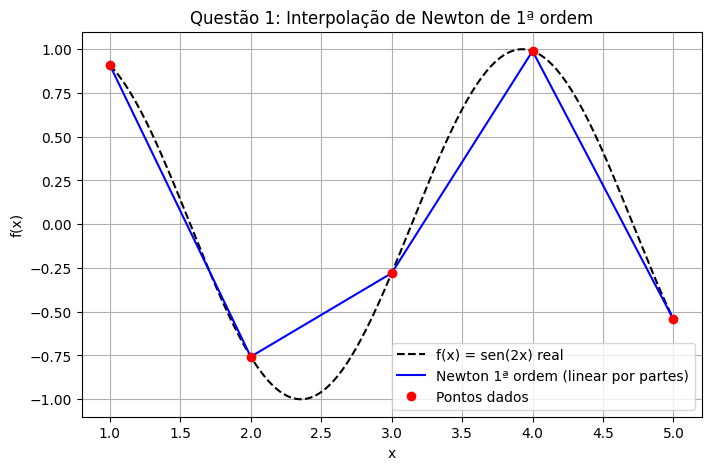

In [32]:
import numpy as np
import matplotlib.pyplot as plt

def f(x):
    return np.sin(2*x)

# Pontos dados
x_pts = np.array([1, 2, 3, 4, 5], dtype=float)
y_pts = f(x_pts)

def newton_1a_ordem(x_eval, x_pts, y_pts):
    """
    Interpolacao de Newton de 1a ordem, aplicada por partes:
    para cada x, usa o par de pontos (x_i, x_i+1) que o envolve.
    """
    x_eval = np.atleast_1d(x_eval).astype(float)
    resultado = np.zeros_like(x_eval)

    for idx, x in enumerate(x_eval):
        i = np.searchsorted(x_pts, x) - 1
        i = np.clip(i, 0, len(x_pts) - 2)

        x0, x1 = x_pts[i], x_pts[i+1]
        y0, y1 = y_pts[i], y_pts[i+1]

        # diferenca dividida de 1a ordem: f[x0,x1]
        f_x0_x1 = (y1 - y0) / (x1 - x0)

        # polinomio de Newton de 1a ordem
        resultado[idx] = y0 + f_x0_x1 * (x - x0)

    return resultado

# Malha fina para plotar
x_malha = np.linspace(1, 5, 200)
y_interp = newton_1a_ordem(x_malha, x_pts, y_pts)
y_real = f(x_malha)

plt.figure(figsize=(8,5))
plt.plot(x_malha, y_real, 'k--', label='f(x) = sen(2x) real')
plt.plot(x_malha, y_interp, 'b-', label='Newton 1ª ordem (linear por partes)')
plt.plot(x_pts, y_pts, 'ro', label='Pontos dados')
plt.legend()
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Questão 1: Interpolação de Newton de 1ª ordem')
plt.grid(True)
plt.show()



---



#Questão 2


Com 5 pontos, a interpolação de 2ª ordem é feita em dois trechos, cada um
usando 3 pontos consecutivos:

$$P_2(x) = f(x_i) + f[x_i,x_{i+1}](x-x_i) + f[x_i,x_{i+1},x_{i+2}](x-x_i)(x-x_{i+1})$$

$$f[x_i,x_{i+1},x_{i+2}] = \frac{f[x_{i+1},x_{i+2}] - f[x_i,x_{i+1}]}{x_{i+2}-x_i}$$

\textbf{Trecho 1} ($x_0,x_1,x_2$, válido para $x\in[1,3]$):

$$f[x_0,x_1]=-1{,}666099,\quad f[x_1,x_2]=0{,}477387,\quad f[x_0,x_1,x_2]=1{,}071743$$
$$P_{012}(x) = 0{,}909297 -1{,}666099(x-1) + 1{,}071743(x-1)(x-2)$$

\textbf{Trecho 2} ($x_2,x_3,x_4$, válido para $x\in[3,5]$):

$$f[x_2,x_3]=1{,}268773,\quad f[x_3,x_4]=-1{,}533379,\quad f[x_2,x_3,x_4]=-1{,}401076$$
$$P_{234}(x) = -0{,}279415 + 1{,}268773(x-3) -1{,}401076(x-3)(x-4)$$

O termo quadrático agora captura parte da curvatura de $\sin(2x)$, então o
erro tende a ser menor que na Questão 1, exceto perto de $x=3$, onde a
troca de trecho pode gerar uma pequena descontinuidade na derivada.

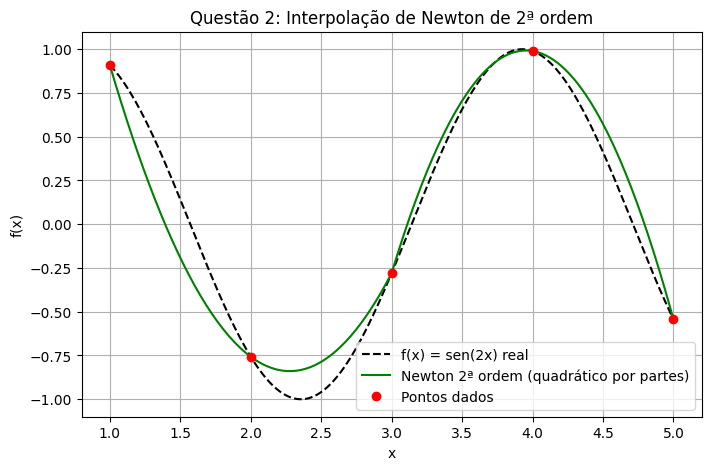

In [33]:
import numpy as np
import matplotlib.pyplot as plt

def f(x):
    return np.sin(2*x)

x_pts = np.array([1, 2, 3, 4, 5], dtype=float)
y_pts = f(x_pts)

def newton_2a_ordem(x_eval, x_pts, y_pts):
    """
    Interpolacao de Newton de 2a ordem, por partes:
    x em [x0,x2] usa o trio (x0,x1,x2); x em [x2,x4] usa o trio (x2,x3,x4).
    """
    x_eval = np.atleast_1d(x_eval).astype(float)
    resultado = np.zeros_like(x_eval)

    for idx, x in enumerate(x_eval):
        i0 = 0 if x <= x_pts[2] else 2  # escolhe o trio
        x0, x1, x2 = x_pts[i0], x_pts[i0+1], x_pts[i0+2]
        y0, y1, y2 = y_pts[i0], y_pts[i0+1], y_pts[i0+2]

        f01 = (y1 - y0) / (x1 - x0)
        f12 = (y2 - y1) / (x2 - x1)
        f012 = (f12 - f01) / (x2 - x0)

        resultado[idx] = y0 + f01*(x - x0) + f012*(x - x0)*(x - x1)

    return resultado

x_malha = np.linspace(1, 5, 200)
y_interp = newton_2a_ordem(x_malha, x_pts, y_pts)
y_real = f(x_malha)

plt.figure(figsize=(8,5))
plt.plot(x_malha, y_real, 'k--', label='f(x) = sen(2x) real')
plt.plot(x_malha, y_interp, 'g-', label='Newton 2ª ordem (quadrático por partes)')
plt.plot(x_pts, y_pts, 'ro', label='Pontos dados')
plt.legend()
plt.xlabel('x'); plt.ylabel('f(x)')
plt.title('Questão 2: Interpolação de Newton de 2ª ordem')
plt.grid(True)
plt.show()



---



#Questão 3

$$E = \frac{1}{N}\sum_{i=0}^{N} \left(f(x_i)-f_{int}(x_i)\right)^2, \qquad N=40$$

onde $x_i = 1, 1{,}1, 1{,}2, \dots, 4{,}9, 5$ (41 pontos igualmente espaçados
por $0{,}1$).

Espera-se que o EQM da Questão 2 (quadrático por partes) seja **menor**
que o da Questão 1 (linear por partes), pois o termo de segunda ordem
consegue acompanhar a curvatura de $\sin(2x)$ nos trechos entre os pontos
dados, enquanto a reta da Questão 1 só acerta a inclinação média de cada
intervalo. O erro de ambos tende a ser maior no meio de cada intervalo
(longe dos pontos dados, onde o erro é zero) e menor perto dos $x_i$
originais.

In [34]:
def eqm(y_real, y_aprox, N):
    return np.sum((y_real - y_aprox)**2) / N

# 41 pontos de x=1 a x=5, passo 0.1
x_teste = np.arange(1, 5.0001, 0.1)
y_real = f(x_teste)

y_q1 = newton_1a_ordem(x_teste, x_pts, y_pts)
y_q2 = newton_2a_ordem(x_teste, x_pts, y_pts)

N = 40
EQM_q1 = eqm(y_real, y_q1, N)
EQM_q2 = eqm(y_real, y_q2, N)

print(f"EQM Questão 1 (linear por partes):    {EQM_q1:.6f}")
print(f"EQM Questão 2 (quadrático por partes): {EQM_q2:.6f}")

EQM Questão 1 (linear por partes):    0.043491
EQM Questão 2 (quadrático por partes): 0.023487




---



#Questão 4

Para a extrapolação, usamos os mesmos polinômios já construídos nas
Questões 1 e 2 (o último trecho de cada um: $P_{34}(x)$ na Questão 1 e
$P_{234}(x)$ na Questão 2), agora avaliados fora do intervalo de ajuste
$[1,5]$, nos pontos $x_0=5{,}1,\dots,x_9=6$:

$$E_{extrap} = \frac{1}{N}\sum_{i=0}^{N}\left(f(x_i)-f_{int}(x_i)\right)^2$$

Espera-se que $E_{extrap} \gg E_{interp}$ (Questão 3), pois fora do
intervalo onde os pontos foram ajustados os polinômios perdem qualquer
garantia de proximidade com $f(x)$: eles continuam seguindo a tendência
(reta ou parábola) do último trecho, enquanto $\sin(2x)$ continua
oscilando. O erro cresce rapidamente com a distância a $x=5$, e cresce
mais rápido ainda para o polinômio quadrático, cujo termo $(x-x_i)(x-x_j)$
diverge mais rápido que o termo linear à medida que $x$ se afasta do
intervalo ajustado.

Comportamento observado: como esperado, o erro de extrapolação é muito maior que o de interpolação nos dois casos. Em ambos, saímos da região "ancorada" pelos pontos dados. Mas o resultado mais interessante é que a extrapolação da Questão 2 (quadrática) é pior que a da Questão 1 (linear), mesmo tendo sido melhor dentro do intervalo de ajuste. Isso acontece porque o termo (x−xi)(x−xj)(x-x_i)(x-x_j)
(x−xi​)(x−xj​) do polinômio quadrático cresce muito mais rápido que o termo linear conforme
x se afasta do intervalo [1,5][1,5]
[1,5]. Ou seja, quanto maior o grau do polinômio, mais "violenta" é a divergência fora da região onde ele foi ajustado. Isso ilustra bem por que extrapolar com polinômios de grau alto é arriscado.

In [35]:
# ---- Questão 4: extrapolação ----
x_extrap = np.arange(5.1, 6.0001, 0.1)
y_real_extrap = f(x_extrap)

y_q1_extrap = newton_1a_ordem(x_extrap, x_pts, y_pts)
y_q2_extrap = newton_2a_ordem(x_extrap, x_pts, y_pts)

N_extrap = len(x_extrap) - 1  # 9
EQM_q1_extrap = eqm(y_real_extrap, y_q1_extrap, N_extrap)
EQM_q2_extrap = eqm(y_real_extrap, y_q2_extrap, N_extrap)

print(f"EQM extrapolação Q1 (linear):     {EQM_q1_extrap:.6f}")
print(f"EQM extrapolação Q2 (quadrático): {EQM_q2_extrap:.6f}")

EQM extrapolação Q1 (linear):     0.627119
EQM extrapolação Q2 (quadrático): 5.896961




---



#Questão 5

Tabela de diferenças divididas ($x_0=1,x_1=2,x_2=3,x_3=4$):

$$f[x_0,x_1]=-1{,}666099,\quad f[x_1,x_2]=0{,}477387,\quad f[x_2,x_3]=1{,}268773$$
$$f[x_0,x_1,x_2]=1{,}071743,\quad f[x_1,x_2,x_3]=0{,}395693$$
$$f[x_0,x_1,x_2,x_3]=-0{,}225350$$

Polinômio de Newton de 3ª ordem:

$$P_3(x) = f_0 + f[x_0,x_1](x-x_0) + f[x_0,x_1,x_2](x-x_0)(x-x_1)
+ f[x_0,x_1,x_2,x_3](x-x_0)(x-x_1)(x-x_2)$$

$$P_3(x) = 0{,}909297 -1{,}666099(x-1) + 1{,}071743(x-1)(x-2)
-0{,}225350(x-1)(x-2)(x-3)$$

In [36]:
def diferencas_divididas(x_pts, y_pts):
    """Retorna a tabela de diferenças divididas (matriz triangular)."""
    n = len(x_pts)
    tabela = np.zeros((n, n))
    tabela[:, 0] = y_pts
    for j in range(1, n):
        for i in range(n - j):
            tabela[i, j] = (tabela[i+1, j-1] - tabela[i, j-1]) / (x_pts[i+j] - x_pts[i])
    return tabela

def newton_polinomio(x_eval, x_pts, y_pts):
    """Avalia o polinômio de Newton (grau len(x_pts)-1)."""
    tabela = diferencas_divididas(x_pts, y_pts)
    coefs = tabela[0, :]
    n = len(x_pts)

    x_eval = np.atleast_1d(x_eval).astype(float)
    resultado = np.zeros_like(x_eval)
    for idx, x in enumerate(x_eval):
        soma = coefs[0]
        produto = 1.0
        for k in range(1, n):
            produto *= (x - x_pts[k-1])
            soma += coefs[k] * produto
        resultado[idx] = soma
    return resultado

x_pts4 = np.array([1, 2, 3, 4], dtype=float)
y_pts4 = np.sin(2 * x_pts4)

x_malha = np.linspace(1, 4, 200)
y_interp = newton_polinomio(x_malha, x_pts4, y_pts4)



---



#Questão 6

| $x_i$ | $f(x_i)$ | 1ª ordem | 2ª ordem | 3ª ordem |
|---|---|---|---|---|
| 1 | 0,909297 | | | |
| | | -1,666099 | | |
| 2 | -0,756802 | | 1,071743 | |
| | | 0,477387 | | -0,225350 |
| 3 | -0,279415 | | 0,395693 | |
| | | 1,268773 | | |
| 4 | 0,989358 | | | |

In [37]:
import pandas as pd

tabela = diferencas_divididas(x_pts4, y_pts4)  # já criada na Questão 5

n = len(x_pts4)
colunas = ['x', 'f(x)'] + [f'{k}ª ordem' for k in range(1, n)]
dados = []
for i in range(n):
    linha = [x_pts4[i]] + [tabela[i, j] if i + j < n else np.nan for j in range(n)]
    dados.append(linha)

df = pd.DataFrame(dados, columns=colunas)
print(df.to_string(index=False, na_rep='', float_format=lambda v: f'{v:.6f}'))

       x      f(x)  1ª ordem  2ª ordem  3ª ordem
1.000000  0.909297 -1.666100  1.071743 -0.225350
2.000000 -0.756802  0.477387  0.395693          
3.000000 -0.279415  1.268774                    
4.000000  0.989358                              




---



#Questão 7

Buscamos um polinômio $P_3(x) = a_0 + a_1x + a_2x^2 + a_3x^3$ que passe
pelos pontos $x_0=1,x_1=2,x_2=3,x_3=4$. Isso gera um sistema linear
$4\times 4$ (matriz de Vandermonde):

$$
\begin{bmatrix}
1 & x_0 & x_0^2 & x_0^3 \\
1 & x_1 & x_1^2 & x_1^3 \\
1 & x_2 & x_2^2 & x_2^3 \\
1 & x_3 & x_3^2 & x_3^3
\end{bmatrix}
\begin{bmatrix} a_0 \\ a_1 \\ a_2 \\ a_3 \end{bmatrix}
=
\begin{bmatrix} f(x_0) \\ f(x_1) \\ f(x_2) \\ f(x_3) \end{bmatrix}
$$

Substituindo os valores numéricos e resolvendo o sistema (por eliminação
de Gauss ou inversão de matriz, inviável fazer à mão com precisão, então
resolvemos numericamente), obtemos os coeficientes $a_0,a_1,a_2,a_3$.
Como o polinômio interpolador de grau 3 que passa por 4 pontos é
**único**, o resultado deve ser algebricamente idêntico ao $P_3(x)$
da Questão 5 (apenas escrito na base de monômios ao invés da base de
Newton).


In [38]:
def interp_sistema_linear(x_eval, x_pts, y_pts):
    """
    Monta a matriz de Vandermonde e resolve o sistema linear para achar
    os coeficientes na base de monômios: a0 + a1*x + ... + an*x^n
    """
    n = len(x_pts)
    A = np.vander(x_pts, N=n, increasing=True)  # colunas: 1, x, x^2, ..., x^(n-1)
    a = np.linalg.solve(A, y_pts)

    x_eval = np.atleast_1d(x_eval).astype(float)
    resultado = np.zeros_like(x_eval)
    for k in range(n):
        resultado += a[k] * x_eval**k
    return resultado, a

x_pts4 = np.array([1, 2, 3, 4], dtype=float)
y_pts4 = np.sin(2 * x_pts4)

x_malha = np.linspace(1, 4, 200)
y_interp, coefs = interp_sistema_linear(x_malha, x_pts4, y_pts4)
print("Coeficientes [a0, a1, a2, a3]:", coefs)

Coeficientes [a0, a1, a2, a3]: [ 6.07098444 -7.36018062  2.42384363 -0.22535003]




---



#Questão 8

Como o polinômio interpolador de grau 3 que passa por 4 pontos é único,
o polinômio da Questão 5 (base de Newton) e o da Questão 7 (base de
monômios, via sistema linear) são **algebricamente o mesmo
polinômio**, apenas escritos de formas diferentes. Portanto, é esperado
que:

$$E_{Q5} = E_{Q7}$$

a menos de diferenças numéricas desprezíveis (erro de arredondamento de
ponto flutuante, da ordem de $10^{-14}$ a $10^{-16}$), já que os dois
métodos resolvem o mesmo problema matemático por caminhos numéricos
distintos.

Vale notar que esse EQM é calculado sobre $x \in [1,5]$, mas o polinômio
foi ajustado só com $x_0,x_1,x_2,x_3$ (até $x=4$). Ou seja, o trecho
$[4,5]$ é, na prática, extrapolação, o que deve aumentar o EQM combinado
em relação ao que seria obtido avaliando só dentro de $[1,4]$.

In [39]:
import numpy as np

def f(x):
    return np.sin(2*x)

x_pts4 = np.array([1, 2, 3, 4], dtype=float)
y_pts4 = f(x_pts4)

def diferencas_divididas(x_pts, y_pts):
    n = len(x_pts)
    tabela = np.zeros((n, n))
    tabela[:, 0] = y_pts
    for j in range(1, n):
        for i in range(n - j):
            tabela[i, j] = (tabela[i+1, j-1] - tabela[i, j-1]) / (x_pts[i+j] - x_pts[i])
    return tabela

def newton_polinomio(x_eval, x_pts, y_pts):
    tabela = diferencas_divididas(x_pts, y_pts)
    coefs = tabela[0, :]
    n = len(x_pts)
    x_eval = np.atleast_1d(x_eval).astype(float)
    resultado = np.zeros_like(x_eval)
    for idx, x in enumerate(x_eval):
        soma = coefs[0]
        produto = 1.0
        for k in range(1, n):
            produto *= (x - x_pts[k-1])
            soma += coefs[k] * produto
        resultado[idx] = soma
    return resultado

def interp_sistema_linear(x_eval, x_pts, y_pts):
    n = len(x_pts)
    A = np.vander(x_pts, N=n, increasing=True)
    a = np.linalg.solve(A, y_pts)
    x_eval = np.atleast_1d(x_eval).astype(float)
    resultado = np.zeros_like(x_eval)
    for k in range(n):
        resultado += a[k] * x_eval**k
    return resultado

def eqm(y_real, y_aprox, N):
    return np.sum((y_real - y_aprox)**2) / N

# Mesmos 41 pontos de teste da Questão 3
x_teste = np.arange(1, 5.0001, 0.1)
y_real = f(x_teste)

y_q5 = newton_polinomio(x_teste, x_pts4, y_pts4)
y_q7 = interp_sistema_linear(x_teste, x_pts4, y_pts4)

N = 40
EQM_q5 = eqm(y_real, y_q5, N)
EQM_q7 = eqm(y_real, y_q7, N)

print(f"EQM Questão 5 (Newton, base de diferenças divididas): {EQM_q5:.10f}")
print(f"EQM Questão 7 (sistema linear, base de monômios):     {EQM_q7:.10f}")
print(f"Diferença absoluta entre os dois EQMs: {abs(EQM_q5-EQM_q7):.2e}")

EQM Questão 5 (Newton, base de diferenças divididas): 0.5300034907
EQM Questão 7 (sistema linear, base de monômios):     0.5300034907
Diferença absoluta entre os dois EQMs: 2.78e-15




---



#Questão 9

Com 5 pontos há 4 segmentos: $S_i(x) = a_i + b_i(x-x_{i-1}) + c_i(x-x_{i-1})^2$,
$i=1,\dots,4$, cada um válido em $[x_{i-1},x_i]$ — 12 incógnitas ($a_i,b_i,c_i$).

**Condições (12 equações):**

1. $S_i(x_{i-1}) = f(x_{i-1})$, $i=1,\dots,4$ (4 eqs) $\Rightarrow a_i = f(x_{i-1})$
2. $S_i(x_i) = f(x_i)$, $i=1,\dots,4$ (4 eqs)
3. $S_i'(x_i) = S_{i+1}'(x_i)$, $i=1,2,3$ (3 eqs, continuidade da derivada)
4. $c_1 = 0$ (1 eq, condição extra: primeiro segmento é reto/linear)

Como $a_i$ já é conhecido diretamente de (1), o sistema restante (8
incógnitas $b_i,c_i$, 8 equações de (2)+(3)+(4)) é resolvido
numericamente, inviável de resolver à mão para todos os 4 segmentos
simultaneamente com precisão razoável.

In [40]:
def spline_quadratica(x_pts, y_pts):
    """
    Monta e resolve o sistema linear das splines quadráticas.
    S_i(x) = a_i + b_i*(x - x_{i-1}) + c_i*(x - x_{i-1})^2
    """
    n = len(x_pts) - 1
    h = np.diff(x_pts)
    a = y_pts[:-1].copy()  # a_i = f(x_{i-1})

    num_incog = 2 * n
    A = np.zeros((num_incog, num_incog))
    rhs = np.zeros(num_incog)
    linha = 0

    # S_i(x_i) = f(x_i)
    for i in range(n):
        A[linha, 2*i] = h[i]
        A[linha, 2*i+1] = h[i]**2
        rhs[linha] = y_pts[i+1] - a[i]
        linha += 1

    # continuidade da derivada nos pontos internos
    for i in range(n - 1):
        A[linha, 2*i] = 1
        A[linha, 2*i+1] = 2*h[i]
        A[linha, 2*(i+1)] = -1
        linha += 1

    # condicao extra: c_1 = 0
    A[linha, 1] = 1

    sol = np.linalg.solve(A, rhs)
    return a, sol[0::2], sol[1::2]  # a, b, c

a, b, c = spline_quadratica(x_pts, y_pts)



---



#Questão 10

**1. $S_i(x_{i-1}) = f(x_{i-1})$ e $S_i(x_i) = f(x_i)$ — Interpolação nos pontos dados**

Cada segmento precisa passar exatamente pelos dois pontos que definem seu
intervalo. Essa é a condição mais básica: garante que a spline realmente
*interpola* a função (não só se aproxima dela) e, de quebra, garante a
continuidade da própria função entre segmentos vizinhos, já que o ponto
final de um segmento é o ponto inicial do próximo, e ambos são obrigados
a valer $f(x_i)$ ali.

**2. $S_i'(x_i) = S_{i+1}'(x_i)$ — Continuidade da primeira derivada**

Sem essa condição, a curva ainda seria contínua (pela condição 1), mas
poderia ter "quinas" nos pontos internos, mudanças bruscas de
inclinação, como na Questão 1 (linear por partes). Impor que a derivada
também seja contínua nos pontos internos ($x_1,x_2,x_3$) garante uma
curva suave, sem quebras visuais de inclinação.

**3. $c_1 = 0$ — Condição extra (arbitrária) para fechar o sistema**

Contando as incógnitas: $3n$ coeficientes ($a_i,b_i,c_i$ para $n=4$
segmentos) $= 12$ incógnitas. As condições 1 e 2 juntas fornecem apenas

$$2n + (n-1) = 11$$

equações. Falta uma equação para o sistema ter solução única. A escolha
mais comum (e a que usamos) é impor $c_1=0$, tornando o primeiro
segmento uma reta (curvatura nula no início).



---



#Questão 11

Com 5 pontos há 4 segmentos: $S_i(x) = a_i + b_i(x-x_i) + c_i(x-x_i)^2 + d_i(x-x_i)^3$,
$i=0,\dots,3$ — 16 incógnitas. Usamos a formulação clássica em termos das
segundas derivadas $M_i = S''(x_i)$ nos nós.

Impondo continuidade de $S$, $S'$ e $S''$ nos pontos internos, chega-se
ao sistema tridiagonal (com $h_i = x_{i+1}-x_i$):

$$h_{i-1}M_{i-1} + 2(h_{i-1}+h_i)M_i + h_iM_{i+1} = 6\left(\frac{f(x_{i+1})-f(x_i)}{h_i} - \frac{f(x_i)-f(x_{i-1})}{h_{i-1}}\right), \quad i=1,2,3$$

Fechamos o sistema com a **condição natural** (a mesma exigida na
Questão 12): $M_0 = 0$ e $M_4 = 0$ (curvatura nula nas extremidades).

Resolvido o sistema, os coeficientes de cada
segmento são:

$$a_i = f(x_i), \qquad b_i = \frac{f(x_{i+1})-f(x_i)}{h_i} - \frac{h_i(2M_i+M_{i+1})}{6}$$
$$c_i = \frac{M_i}{2}, \qquad d_i = \frac{M_{i+1}-M_i}{6h_i}$$

In [ ]:
def spline_cubica_natural(x_pts, y_pts):
    """
    Resolve o sistema tridiagonal da spline cúbica natural (M0=Mn=0).
    S_i(x) = a_i + b_i*(x-x_i) + c_i*(x-x_i)^2 + d_i*(x-x_i)^3
    """
    n = len(x_pts) - 1
    h = np.diff(x_pts)

    A = np.zeros((n+1, n+1))
    rhs = np.zeros(n+1)
    A[0, 0] = 1   # M_0 = 0
    A[n, n] = 1   # M_n = 0

    for i in range(1, n):
        A[i, i-1] = h[i-1]
        A[i, i]   = 2*(h[i-1] + h[i])
        A[i, i+1] = h[i]
        rhs[i] = 6 * ((y_pts[i+1]-y_pts[i])/h[i] - (y_pts[i]-y_pts[i-1])/h[i-1])

    M = np.linalg.solve(A, rhs)

    a = y_pts[:-1].copy()
    b = np.zeros(n); c = np.zeros(n); d = np.zeros(n)
    for i in range(n):
        b[i] = (y_pts[i+1]-y_pts[i])/h[i] - h[i]*(2*M[i]+M[i+1])/6
        c[i] = M[i]/2
        d[i] = (M[i+1]-M[i])/(6*h[i])

    return a, b, c, d, M

a, b, c, d, M = spline_cubica_natural(x_pts, y_pts)



---



#Questão 12

**1. $S_i(x_i) = f(x_i)$ e $S_i(x_{i+1}) = f(x_{i+1})$ — Interpolação nos pontos dados**

Cada um dos 4 segmentos cúbicos precisa passar exatamente pelos dois
pontos que o definem. Assim como nas splines quadráticas, essa condição
garante a interpolação e, como consequência, a continuidade da própria
função $S(x)$ nos pontos internos (o final de um segmento coincide com
o início do próximo).

**2. $S_i'(x_{i+1}) = S_{i+1}'(x_{i+1})$ — Continuidade da primeira derivada**

Garante que não haja "quinas" nos pontos internos $x_1,x_2,x_3$. A
inclinação da curva muda suavemente ao passar de um segmento pro outro,
igual na spline quadrática.

**3. $S_i''(x_{i+1}) = S_{i+1}''(x_{i+1})$ — Continuidade da segunda derivada**

Essa é a condição que a spline **quadrática não conseguia impor** (lá só
tínhamos graus de liberdade suficientes para continuidade da 1ª derivada).
Com o grau extra do polinômio cúbico, sobra folga para também exigir que
a curvatura ($S''$) mude suavemente entre segmentos, daí a spline cúbica
resultar visualmente mais suave e sem variações bruscas de concavidade.

**4. Condições de contorno: $S_0''(x_0) = 0$ e $S_3''(x_4) = 0$ — Spline natural**

Diferente da spline quadrática (onde precisamos impor $c_1=0$ de forma
arbitrária só para fechar o sistema), aqui a condição de contorno tem
uma interpretação física clara: força a curvatura a ser nula nas
extremidades do domínio. Contando graus de liberdade: são 16
incógnitas ($4$ coeficientes $\times$ 4 segmentos), as condições 1–3
fornecem $4+4+3+3=14$ equações, e as 2 condições de contorno completam
exatamente as 16 equações necessárias.





---

